# COVID-19 Data Analysis — India (2020–2022)

## 1. Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Exploratory Analysis

In [2]:
df = pd.read_csv("Covid19.csv")
df.head()

,location_key,date,place_id,wikidata_id,datacommons_id,country_code,country_name,iso_3166_1_alpha_2,iso_3166_1_alpha_3,aggregation_level,...,investment_in_vaccines,facial_coverings,vaccination_policy,stringency_index,average_temperature_celsius,minimum_temperature_celsius,maximum_temperature_celsius,rainfall_mm,dew_point,relative_humidity
0,IN,2020-01-01,ChIJkbeSa_BfYzARphNChaFPjNc,Q668,country/IND,IN,India,IN,IND,0,...,0.0,0.0,0.0,0.0,16.642857,12.095238,20.190476,1.378857,11.301587,72.710239
1,IN,2020-01-02,ChIJkbeSa_BfYzARphNChaFPjNc,Q668,country/IND,IN,India,IN,IND,0,...,0.0,0.0,0.0,0.0,16.325397,12.841270,19.079365,6.392333,13.126984,82.579141
2,IN,2020-01-03,ChIJkbeSa_BfYzARphNChaFPjNc,Q668,country/IND,IN,India,IN,IND,0,...,0.0,0.0,0.0,0.0,17.674603,13.555556,20.484127,12.657667,15.674603,88.143746
3,IN,2020-01-04,ChIJkbeSa_BfYzARphNChaFPjNc,Q668,country/IND,IN,India,IN,IND,0,...,0.0,0.0,0.0,0.0,18.412698,14.626984,22.341270,0.399143,15.277778,82.162551
4,IN,2020-01-05,ChIJkbeSa_BfYzARphNChaFPjNc,Q668,country/IND,IN,India,IN,IND,0,...,0.0,0.0,0.0,0.0,17.412698,12.873016,22.087302,0.000000,11.650794,69.406234


In [3]:
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 991 entries, 0 to 990
Columns: 175 entries, location_key to relative_humidity
dtypes: float64(133), int64(23), str(19)
memory usage: 1.3 MB


,aggregation_level,new_confirmed,new_deceased,new_tested,cumulative_confirmed,cumulative_deceased,cumulative_tested,new_persons_vaccinated,cumulative_persons_vaccinated,new_persons_fully_vaccinated,...,investment_in_vaccines,facial_coverings,vaccination_policy,stringency_index,average_temperature_celsius,minimum_temperature_celsius,maximum_temperature_celsius,rainfall_mm,dew_point,relative_humidity
count,991.0,987.000000,987.000000,7.950000e+02,9.870000e+02,987.000000,8.100000e+02,5.870000e+02,5.880000e+02,5.580000e+02,...,9.090000e+02,931.000000,931.000000,931.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000
mean,0.0,45102.815603,535.207700,1.055093e+06,2.155144e+07,275199.267477,3.660221e+08,1.747074e+06,6.257862e+08,1.694670e+06,...,1.432406e+05,3.309345,2.573577,64.092470,26.860736,20.651480,31.998399,3.833061,18.685074,63.881850
std,0.0,75340.192709,853.713805,1.379855e+06,1.704948e+07,207960.359984,2.932974e+08,1.928001e+06,3.835255e+08,1.754736e+06,...,3.904806e+06,1.234325,2.253721,22.818822,4.588366,5.222088,4.819462,7.717433,5.696946,17.448017
min,0.0,-3.000000,0.000000,1.570000e+02,0.000000e+00,0.000000,6.500000e+03,5.671000e+03,0.000000e+00,2.313000e+03,...,0.000000e+00,0.000000,0.000000,0.000000,15.436508,6.951389,17.753968,0.000000,4.388889,26.210685
25%,0.0,6004.500000,45.000000,4.985255e+05,4.068495e+06,70093.500000,8.923136e+07,2.302600e+05,2.097900e+08,3.963840e+05,...,0.000000e+00,3.000000,0.000000,57.405000,23.498264,16.536459,29.038443,0.000000,14.000000,49.777941
50%,0.0,17296.000000,271.000000,1.014079e+06,2.266258e+07,246116.000000,2.976885e+08,1.171620e+06,7.549927e+08,1.055000e+06,...,0.000000e+00,4.000000,4.000000,68.980000,27.840774,23.319444,31.670139,0.269875,19.011905,63.714475
75%,0.0,45897.500000,575.000000,1.411204e+06,3.597315e+07,484434.000000,6.379624e+08,2.594464e+06,9.965873e+08,2.489108e+06,...,0.000000e+00,4.000000,5.000000,81.940000,29.691468,24.618304,34.857391,4.354286,24.514385,79.869825
max,0.0,414188.000000,6148.000000,3.585563e+07,4.451648e+07,528250.000000,8.585264e+08,1.266605e+07,1.025533e+09,1.117515e+07,...,1.170000e+08,4.000000,5.000000,100.000000,37.840278,30.187500,44.048611,62.121143,25.904762,96.190750


In [4]:
df.isnull().sum()

location_key                   0
date                           0
place_id                       0
wikidata_id                    0
datacommons_id                 0
                              ..
minimum_temperature_celsius    7
maximum_temperature_celsius    7
rainfall_mm                    7
dew_point                      7
relative_humidity              7
Length: 175, dtype: int64

## 3. Data Cleaning

In [5]:
covid = df[['date',
            'new_confirmed',
            'new_deceased',
            'new_tested',
            'cumulative_confirmed',
            'cumulative_deceased',
            'cumulative_tested',
            'new_persons_vaccinated',
            'cumulative_persons_vaccinated',
            'new_persons_fully_vaccinated',
            'cumulative_vaccine_doses_administered',
            'stringency_index',
            'mobility_retail_and_recreation',
            'mobility_grocery_and_pharmacy',
            'mobility_parks',
            'mobility_transit_stations',
            'mobility_workplaces',
            'mobility_residential'
        ]].copy()

covid.head()

,date,new_confirmed,new_deceased,new_tested,cumulative_confirmed,cumulative_deceased,cumulative_tested,new_persons_vaccinated,cumulative_persons_vaccinated,new_persons_fully_vaccinated,cumulative_vaccine_doses_administered,stringency_index,mobility_retail_and_recreation,mobility_grocery_and_pharmacy,mobility_parks,mobility_transit_stations,mobility_workplaces,mobility_residential
0,2020-01-01,0.0,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-01-02,0.0,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-01-03,0.0,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-01-04,0.0,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
4,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
covid['date'] = pd.to_datetime(covid['date'])
print("Date range:", covid['date'].min(), "to", covid['date'].max())
print("Country:", df['country_name'].unique())

Date range: 2020-01-01 00:00:00 to 2022-09-17 00:00:00
Country: <StringArray>
['India']
Length: 1, dtype: str


In [7]:
case_cols = ['new_confirmed', 'new_deceased', 'new_tested',
             'cumulative_confirmed', 'cumulative_deceased', 'cumulative_tested']
covid[case_cols] = covid[case_cols].fillna(0)

vax_cols = ['new_persons_vaccinated', 'cumulative_persons_vaccinated',
            'new_persons_fully_vaccinated', 'cumulative_vaccine_doses_administered']
covid[vax_cols] = covid[vax_cols].fillna(0)

covid['stringency_index'] = covid['stringency_index'].ffill().fillna(0)

mob_cols = ['mobility_retail_and_recreation', 'mobility_grocery_and_pharmacy',
            'mobility_parks', 'mobility_transit_stations',
            'mobility_workplaces', 'mobility_residential']
covid[mob_cols] = covid[mob_cols].ffill().fillna(0)

print("Nulls remaining:\n", covid.isnull().sum())

Nulls remaining:
 date                                     0
new_confirmed                            0
new_deceased                             0
new_tested                               0
cumulative_confirmed                     0
cumulative_deceased                      0
cumulative_tested                        0
new_persons_vaccinated                   0
cumulative_persons_vaccinated            0
new_persons_fully_vaccinated             0
cumulative_vaccine_doses_administered    0
stringency_index                         0
mobility_retail_and_recreation           0
mobility_grocery_and_pharmacy            0
mobility_parks                           0
mobility_transit_stations                0
mobility_workplaces                      0
mobility_residential                     0
dtype: int64


In [8]:
covid['new_confirmed'] = covid['new_confirmed'].clip(lower=0)
covid['new_deceased']  = covid['new_deceased'].clip(lower=0)
covid['new_tested']    = covid['new_tested'].clip(lower=0)

print("Negative values remaining:\n", (covid[case_cols] < 0).sum())

Negative values remaining:
 new_confirmed           0
new_deceased            0
new_tested              0
cumulative_confirmed    0
cumulative_deceased     0
cumulative_tested       0
dtype: int64


In [9]:
print("Final shape:", covid.shape)
print("\nNull count:", covid.isnull().sum().sum(), "(should be 0)")
covid.head()

Final shape: (991, 18)

Null count: 0 (should be 0)


,date,new_confirmed,new_deceased,new_tested,cumulative_confirmed,cumulative_deceased,cumulative_tested,new_persons_vaccinated,cumulative_persons_vaccinated,new_persons_fully_vaccinated,cumulative_vaccine_doses_administered,stringency_index,mobility_retail_and_recreation,mobility_grocery_and_pharmacy,mobility_parks,mobility_transit_stations,mobility_workplaces,mobility_residential
0,2020-01-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2020-01-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2020-01-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2020-01-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2020-01-05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 4. Visualizations

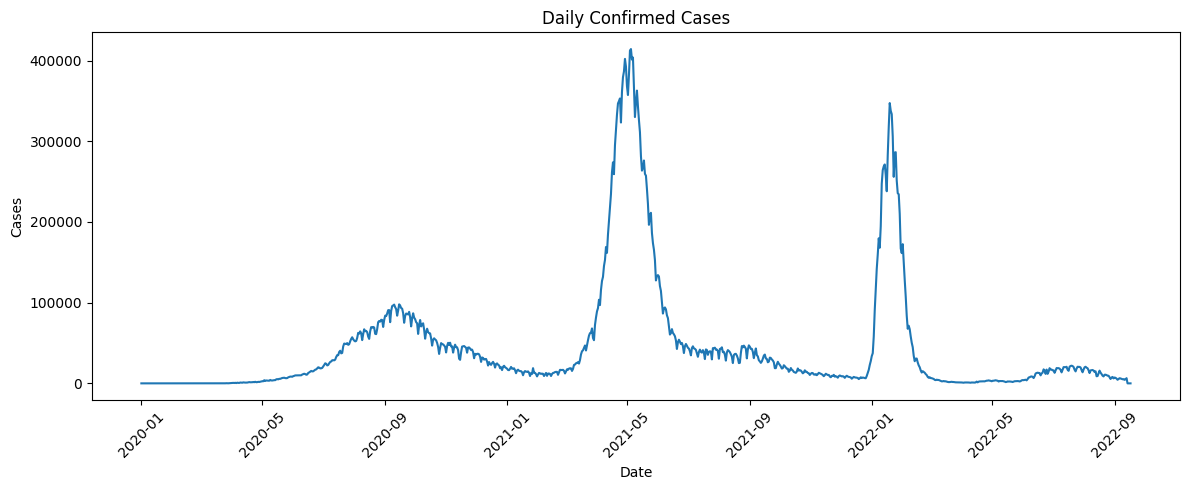

In [10]:
plt.figure(figsize=(12,5))
plt.plot(covid['date'], covid['new_confirmed'])
plt.title("Daily Confirmed Cases")
plt.xlabel("Date")
plt.ylabel("Cases")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

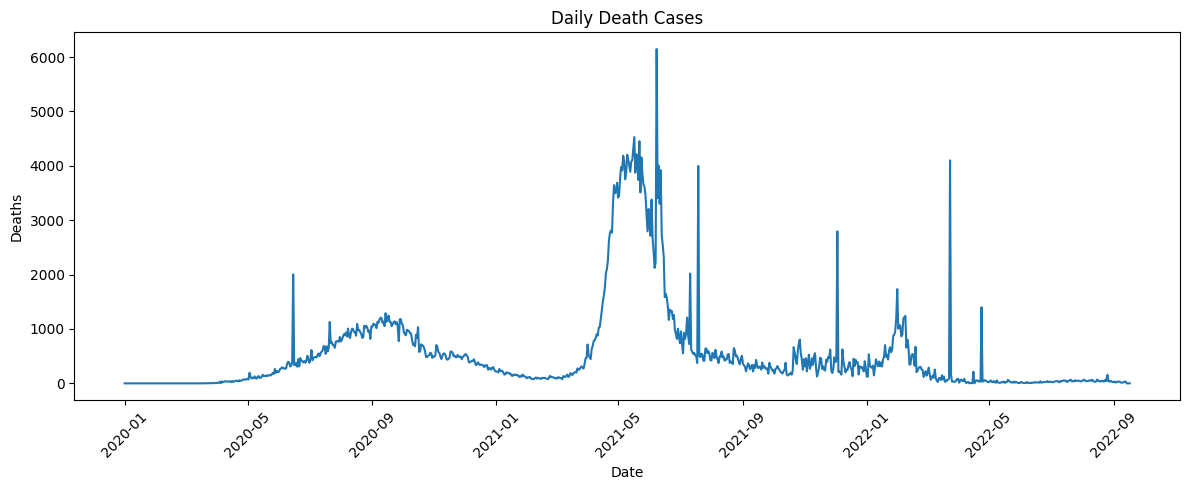

In [11]:
plt.figure(figsize=(12,5))
plt.plot(covid['date'], covid['new_deceased'])
plt.title("Daily Death Cases")
plt.xlabel("Date")
plt.ylabel("Deaths")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

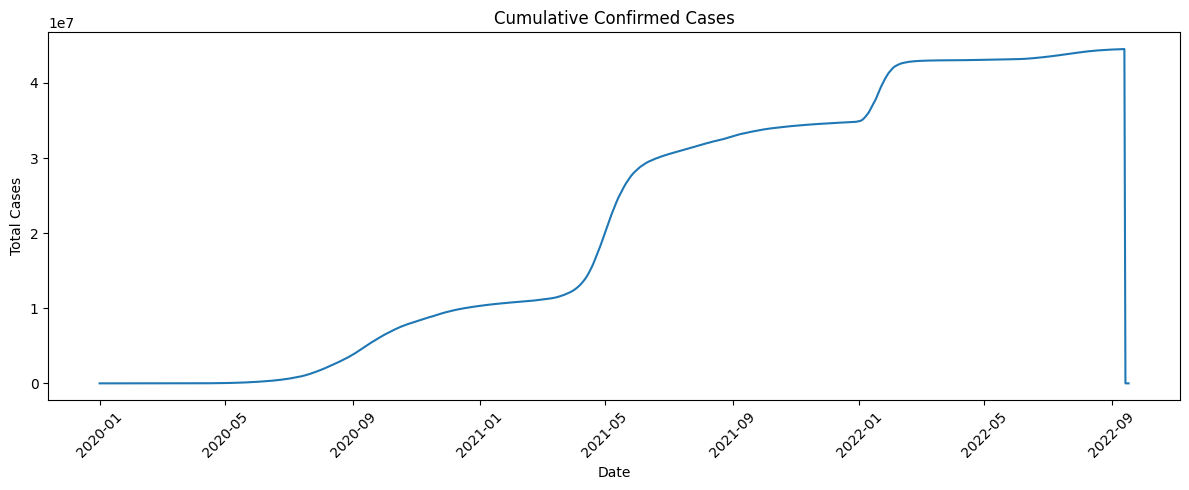

In [12]:
plt.figure(figsize=(12,5))
plt.plot(covid['date'], covid['cumulative_confirmed'])
plt.title("Cumulative Confirmed Cases")
plt.xlabel("Date")
plt.ylabel("Total Cases")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

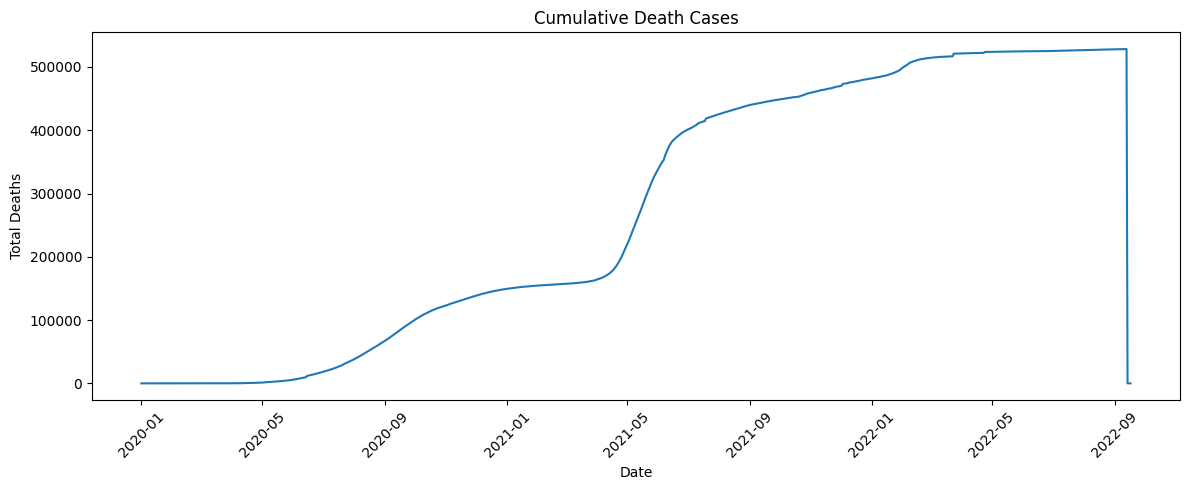

In [13]:
plt.figure(figsize=(12,5))
plt.plot(covid['date'], covid['cumulative_deceased'])
plt.title("Cumulative Death Cases")
plt.xlabel("Date")
plt.ylabel("Total Deaths")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

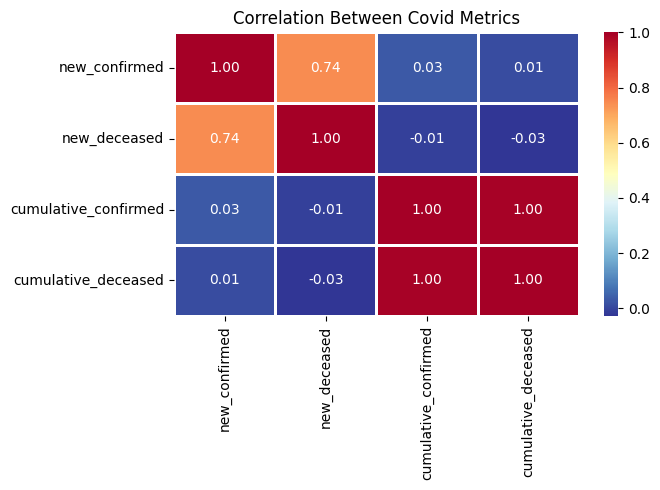

In [14]:
corr_data = covid[
    ['new_confirmed',
     'new_deceased',
     'cumulative_confirmed',
     'cumulative_deceased']
]

corr = corr_data.corr()

plt.figure(figsize=(7,5))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdYlBu_r",
    linewidths=1
)

plt.title("Correlation Between Covid Metrics")
plt.tight_layout()
plt.show()

In [15]:
covid['new_confirmed'].max()

np.float64(414188.0)

In [16]:
covid['new_deceased'].max()

np.float64(6148.0)

In [17]:
print("Maximum Daily Cases:", covid['new_confirmed'].max())
print("Average Daily Cases:", round(covid['new_confirmed'].mean(),2))

print("Maximum Daily Deaths:", covid['new_deceased'].max())
print("Average Daily Deaths:", round(covid['new_deceased'].mean(),2))

Maximum Daily Cases: 414188.0
Average Daily Cases: 44920.77
Maximum Daily Deaths: 6148.0
Average Daily Deaths: 533.05


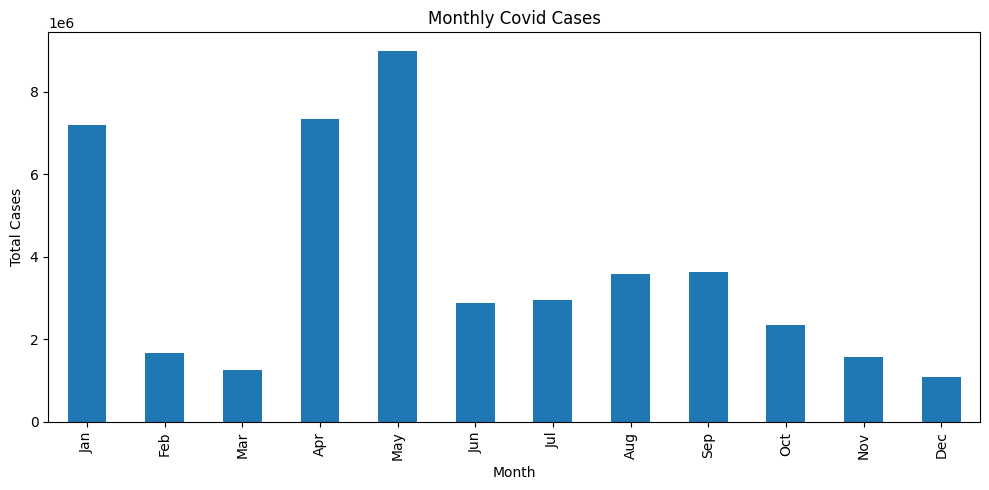

In [18]:
import calendar

covid['month'] = covid['date'].dt.month
monthly_cases = covid.groupby('month')['new_confirmed'].sum()
monthly_cases.index = [calendar.month_abbr[m] for m in monthly_cases.index]

plt.figure(figsize=(10,5))
monthly_cases.plot(kind='bar')
plt.title("Monthly Covid Cases")
plt.xlabel("Month")
plt.ylabel("Total Cases")
plt.tight_layout()
plt.show()

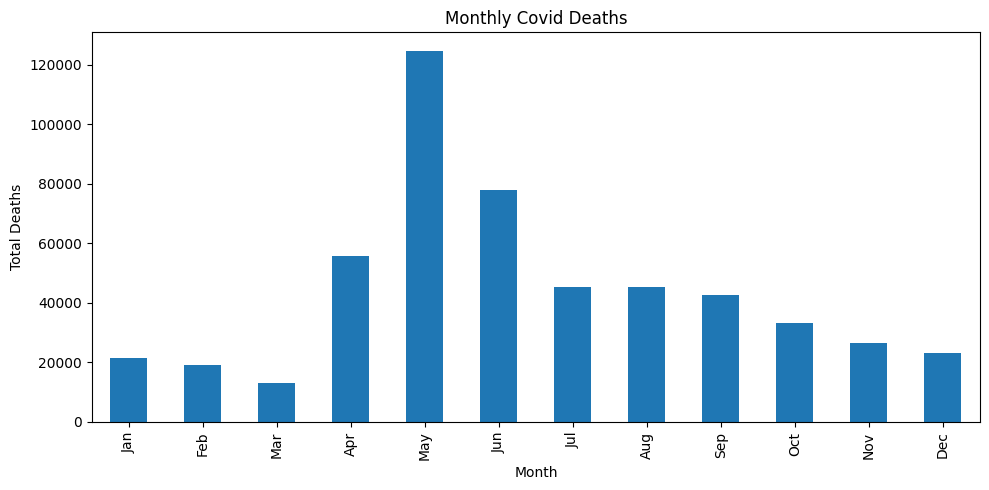

In [19]:
monthly_deaths = covid.groupby('month')['new_deceased'].sum()
monthly_deaths.index = [calendar.month_abbr[m] for m in monthly_deaths.index]

plt.figure(figsize=(10,5))
monthly_deaths.plot(kind='bar')
plt.title("Monthly Covid Deaths")
plt.xlabel("Month")
plt.ylabel("Total Deaths")
plt.tight_layout()
plt.show()

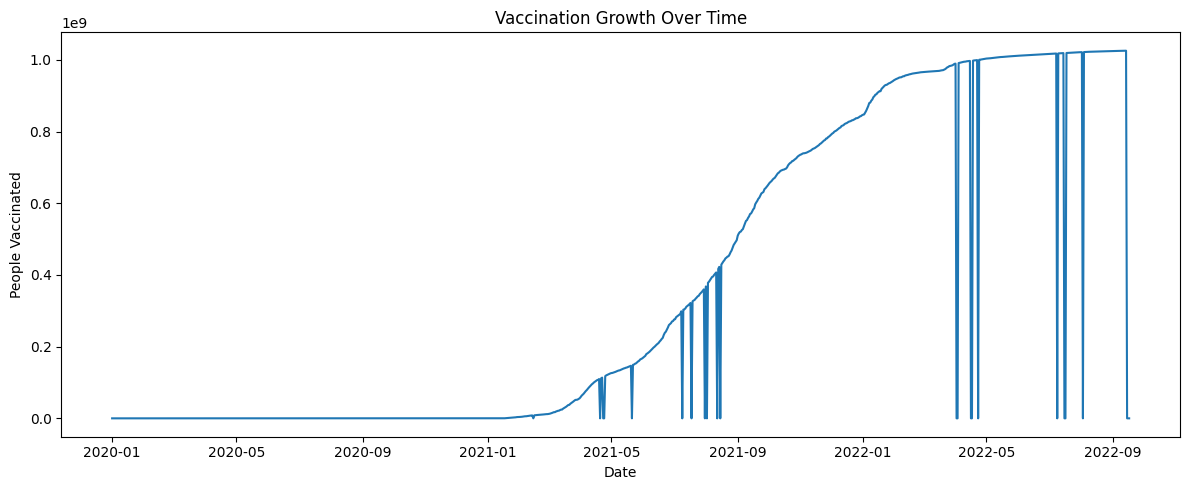

In [20]:
plt.figure(figsize=(12,5))

plt.plot(covid['date'],
         covid['cumulative_persons_vaccinated'])

plt.title("Vaccination Growth Over Time")
plt.xlabel("Date")
plt.ylabel("People Vaccinated")

plt.tight_layout()
plt.show()

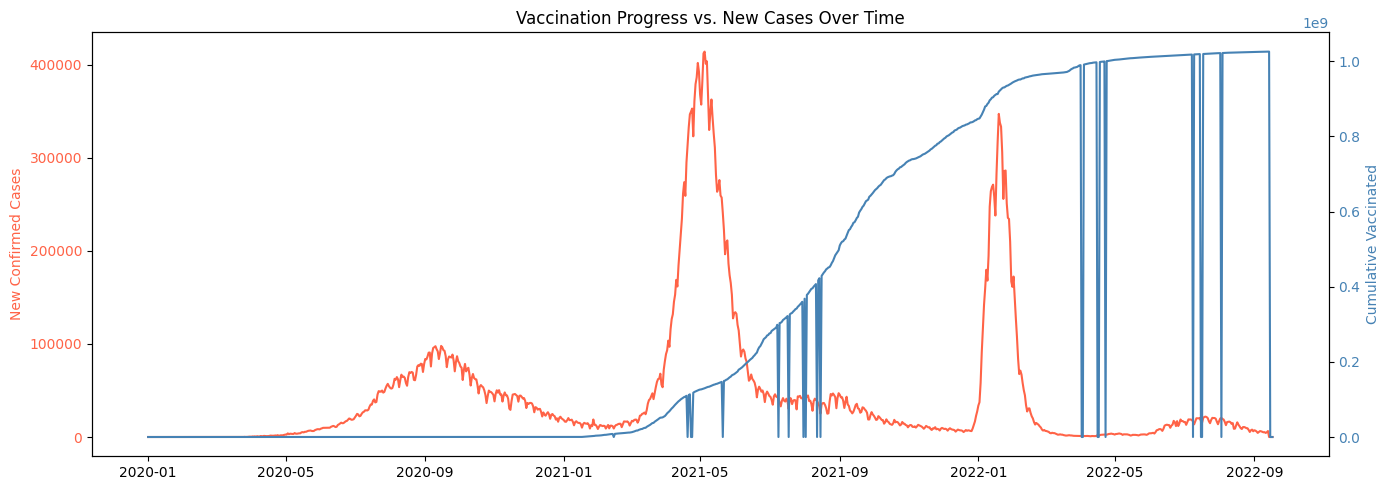

In [21]:
fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(covid['date'], covid['new_confirmed'], color='tomato', label='New Cases')
ax1.set_ylabel('New Confirmed Cases', color='tomato')
ax1.tick_params(axis='y', labelcolor='tomato')

ax2 = ax1.twinx()
ax2.plot(covid['date'], covid['cumulative_persons_vaccinated'], color='steelblue', label='Vaccinated')
ax2.set_ylabel('Cumulative Vaccinated', color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')

plt.title('Vaccination Progress vs. New Cases Over Time')
fig.tight_layout()
plt.show()

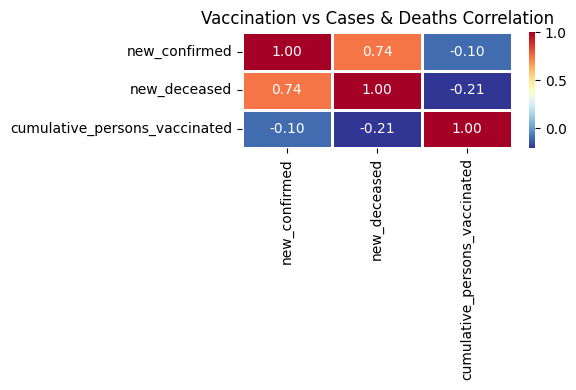

In [22]:
vacc_data = covid[['new_confirmed',
                   'new_deceased',
                   'cumulative_persons_vaccinated']]

plt.figure(figsize=(6,4))
sns.heatmap(vacc_data.corr(), annot=True, fmt=".2f", cmap="RdYlBu_r", linewidths=1)
plt.title("Vaccination vs Cases & Deaths Correlation")
plt.tight_layout()
plt.show()

In [23]:
peak_cases = covid['new_confirmed'].max()
peak_deaths = covid['new_deceased'].max()
total_cases = covid['cumulative_confirmed'].max()
total_deaths = covid['cumulative_deceased'].max()
peak_vax = covid['cumulative_persons_vaccinated'].max()

print(f"Peak Daily Cases     : {int(peak_cases):,}")
print(f"Peak Daily Deaths    : {int(peak_deaths):,}")
print(f"Total Confirmed Cases: {int(total_cases):,}")
print(f"Total Deaths         : {int(total_deaths):,}")
print(f"Total Vaccinated     : {int(peak_vax):,}")

Peak Daily Cases     : 414,188
Peak Daily Deaths    : 6,148
Total Confirmed Cases: 44,516,479
Total Deaths         : 528,250
Total Vaccinated     : 1,025,532,632


## Conclusion

This analysis explored India's COVID-19 data from January 2020 to September 2022
using daily case, death, vaccination, and mobility records.

Key findings:
- **Case waves**: Daily confirmed cases surged in distinct waves, with the highest
  peak observed during the Delta wave (mid-2021), followed by a sharp Omicron-driven
  spike in early 2022.
- **Deaths followed cases**: Daily deaths closely tracked the confirmed case curve
  with a short lag, and showed a strong positive correlation with new confirmed cases.
- **Vaccination rollout**: The vaccination programme began in early 2021 and scaled
  rapidly, with over 1 billion cumulative doses administered by late 2022.
- **Vaccination vs. cases**: As cumulative vaccinations increased, the severity of
  subsequent waves (deaths per case) visibly declined, suggesting a protective effect.
- **Monthly trends**: The analysis confirmed that certain months consistently recorded
  higher case loads, aligning with known wave periods.

Overall, the data highlights how a combination of public health measures and mass
vaccination contributed to controlling the spread and reducing fatalities over time.